# Stores accuracy of each model per dataset


In [ ]:
results = {
    'TrashNet':     {'CNN': 63.83, 'ResNet50': 92.89},
    'RealWaste':    {'CNN': 62.36, 'ResNet50': 91.59},
    'Boarkee':      {'CNN': 67.11, 'ResNet50': 94.74},
    'Kaggle1':      {'CNN': 87.90, 'ResNet50': 94.80},
}


✅ STEP 2: Graph - Side-by-Side Bar Chart



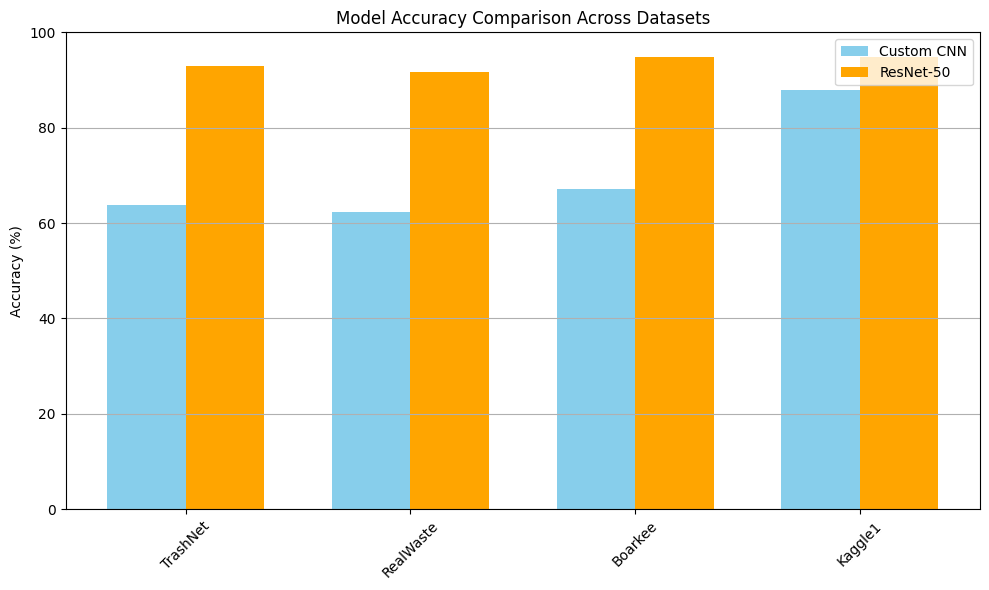

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

datasets = list(results.keys())
cnn_scores = [results[d]['CNN'] for d in datasets]
resnet_scores = [results[d]['ResNet50'] for d in datasets]

x = np.arange(len(datasets))  # label locations
width = 0.35  # bar width

plt.figure(figsize=(10,6))
plt.bar(x - width/2, cnn_scores, width, label='Custom CNN', color='skyblue')
plt.bar(x + width/2, resnet_scores, width, label='ResNet-50', color='orange')

plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison Across Datasets')
plt.xticks(x, datasets, rotation=45)
plt.ylim(0, 100)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()


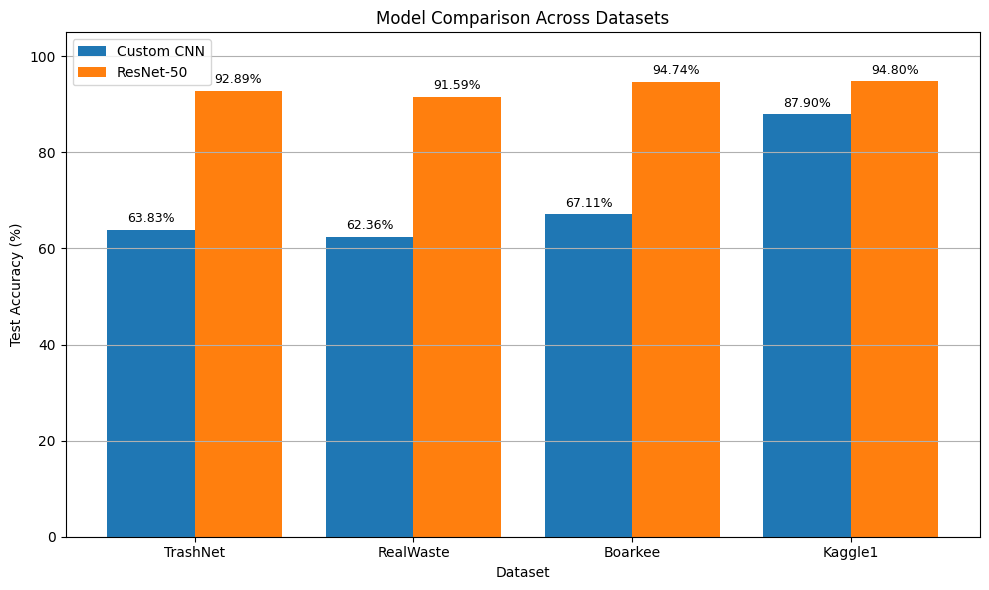

In [ ]:


datasets = list(results.keys())
cnn_scores = [results[ds]['CNN'] for ds in datasets]
resnet_scores = [results[ds]['ResNet50'] for ds in datasets]

x = range(len(datasets))
plt.figure(figsize=(10,6))

# Plot bars
bar1 = plt.bar(x, cnn_scores, width=0.4, label='Custom CNN', align='center')
bar2 = plt.bar([i + 0.4 for i in x], resnet_scores, width=0.4, label='ResNet-50', align='center')

# Annotate bars with values
for i in x:
    plt.text(i, cnn_scores[i] + 1, f"{cnn_scores[i]:.2f}%", ha='center', va='bottom', fontsize=9)
    plt.text(i + 0.4, resnet_scores[i] + 1, f"{resnet_scores[i]:.2f}%", ha='center', va='bottom', fontsize=9)

plt.xlabel('Dataset')
plt.ylabel('Test Accuracy (%)')
plt.title('Model Comparison Across Datasets')
plt.xticks([i + 0.2 for i in x], datasets)
plt.ylim(0, 105)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()


✅ STEP 3: Graph - Line Plot (Optional)


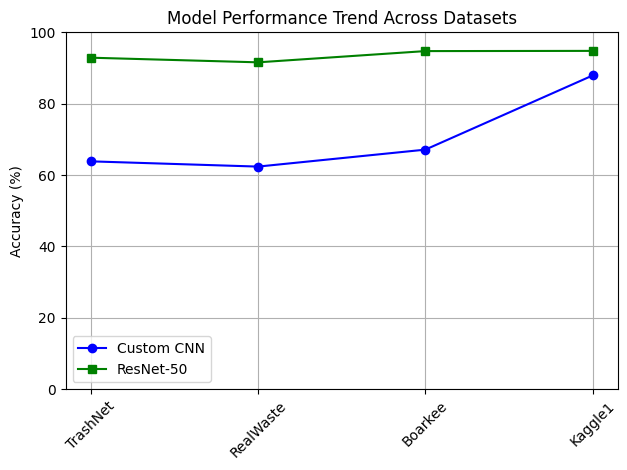

In [ ]:
plt.plot(datasets, cnn_scores, marker='o', label='Custom CNN', color='blue')
plt.plot(datasets, resnet_scores, marker='s', label='ResNet-50', color='green')

plt.ylabel("Accuracy (%)")
plt.title("Model Performance Trend Across Datasets")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


✅ STEP 4: Summary Table (Markdown or Console)



In [ ]:
print("{:<15} {:<12} {:<12}".format("Dataset", "Custom CNN", "ResNet-50"))
print("-"*40)
for dataset, scores in results.items():
    print("{:<15} {:<12.2f} {:<12.2f}".format(dataset, scores['CNN'], scores['ResNet50']))


Dataset         Custom CNN   ResNet-50   
----------------------------------------
TrashNet        63.83        92.89       
RealWaste       62.36        91.59       
Boarkee         67.11        94.74       
Kaggle1         87.90        94.80       


#✅ Model Architecture



✅ Step 1: Install torchviz (Run Once)



In [1]:
!pip install torchviz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

✅ Step 2: Visualize ImprovedCNN Architecture



In [6]:
import torch
import torch.nn as nn

class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128 * 37 * 37, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, xb):
        return self.network(xb)

num_classes = 6  # Change this to match your dataset
model = ImprovedCNN(num_classes)
print("Custom CNN Architecture:")
print(model)


Custom CNN Architecture:
ImprovedCNN(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Dropout(p=0.3, inplace=False)
    (14): Linear(in_features=175232, out_features=256, bias

✅ Custom CNN Architecture:
ImprovedCNN(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Dropout(p=0.3, inplace=False)
    (14): Linear(in_features=175232, out_features=256, bi

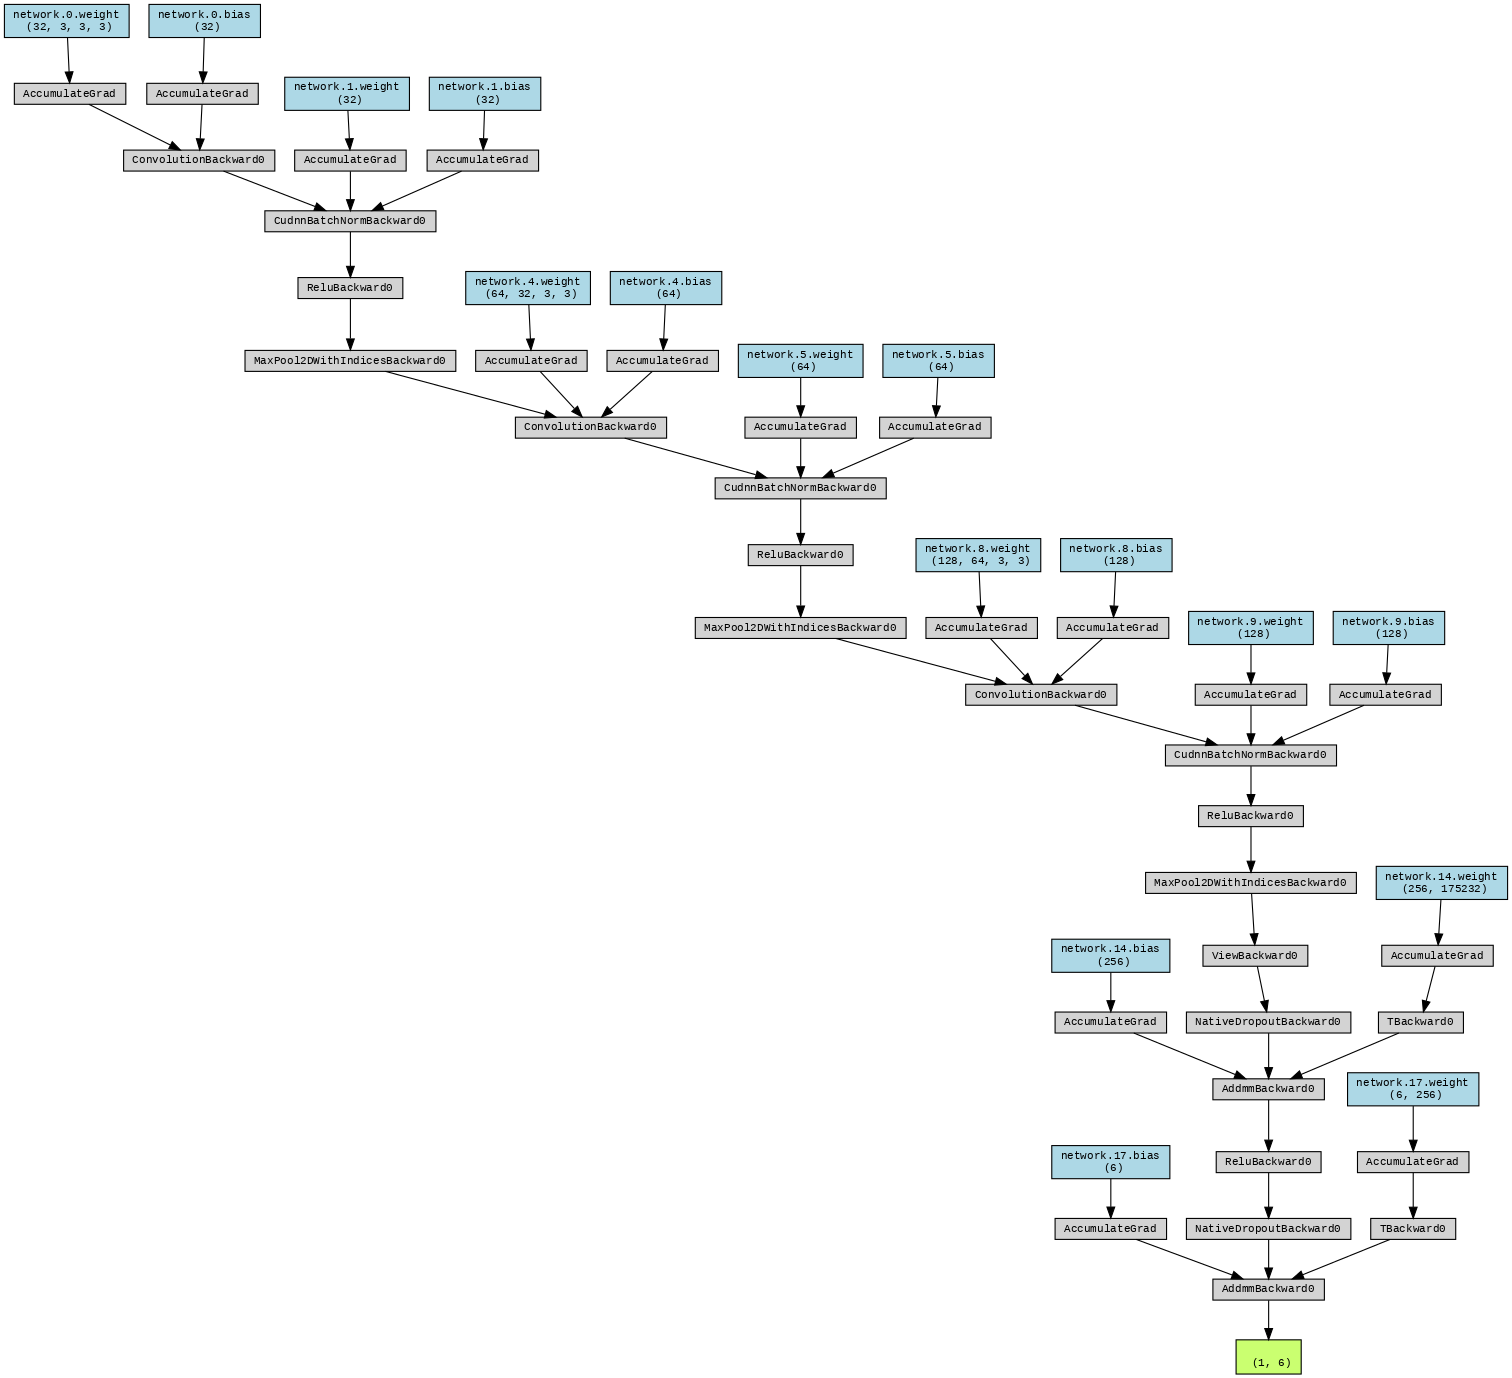

In [8]:
import torch
import torch.nn as nn
from torchviz import make_dot
from IPython.display import Image, display

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define ImprovedCNN
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128 * 37 * 37, 256),  # Adjust if using different input size
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, xb):
        return self.network(xb)

# Initialize model
num_classes = 6
model = ImprovedCNN(num_classes).to(device)
print("✅ Custom CNN Architecture:")
print(model)

# Create dummy input
dummy_input = torch.randn(1, 3, 300, 300).to(device)

# Forward pass & visualize
output = model(dummy_input)
dot = make_dot(output, params=dict(model.named_parameters()))
dot.format = 'png'
dot.render('ImprovedCNN_architecture')

# Display image
display(Image(filename="ImprovedCNN_architecture.png"))


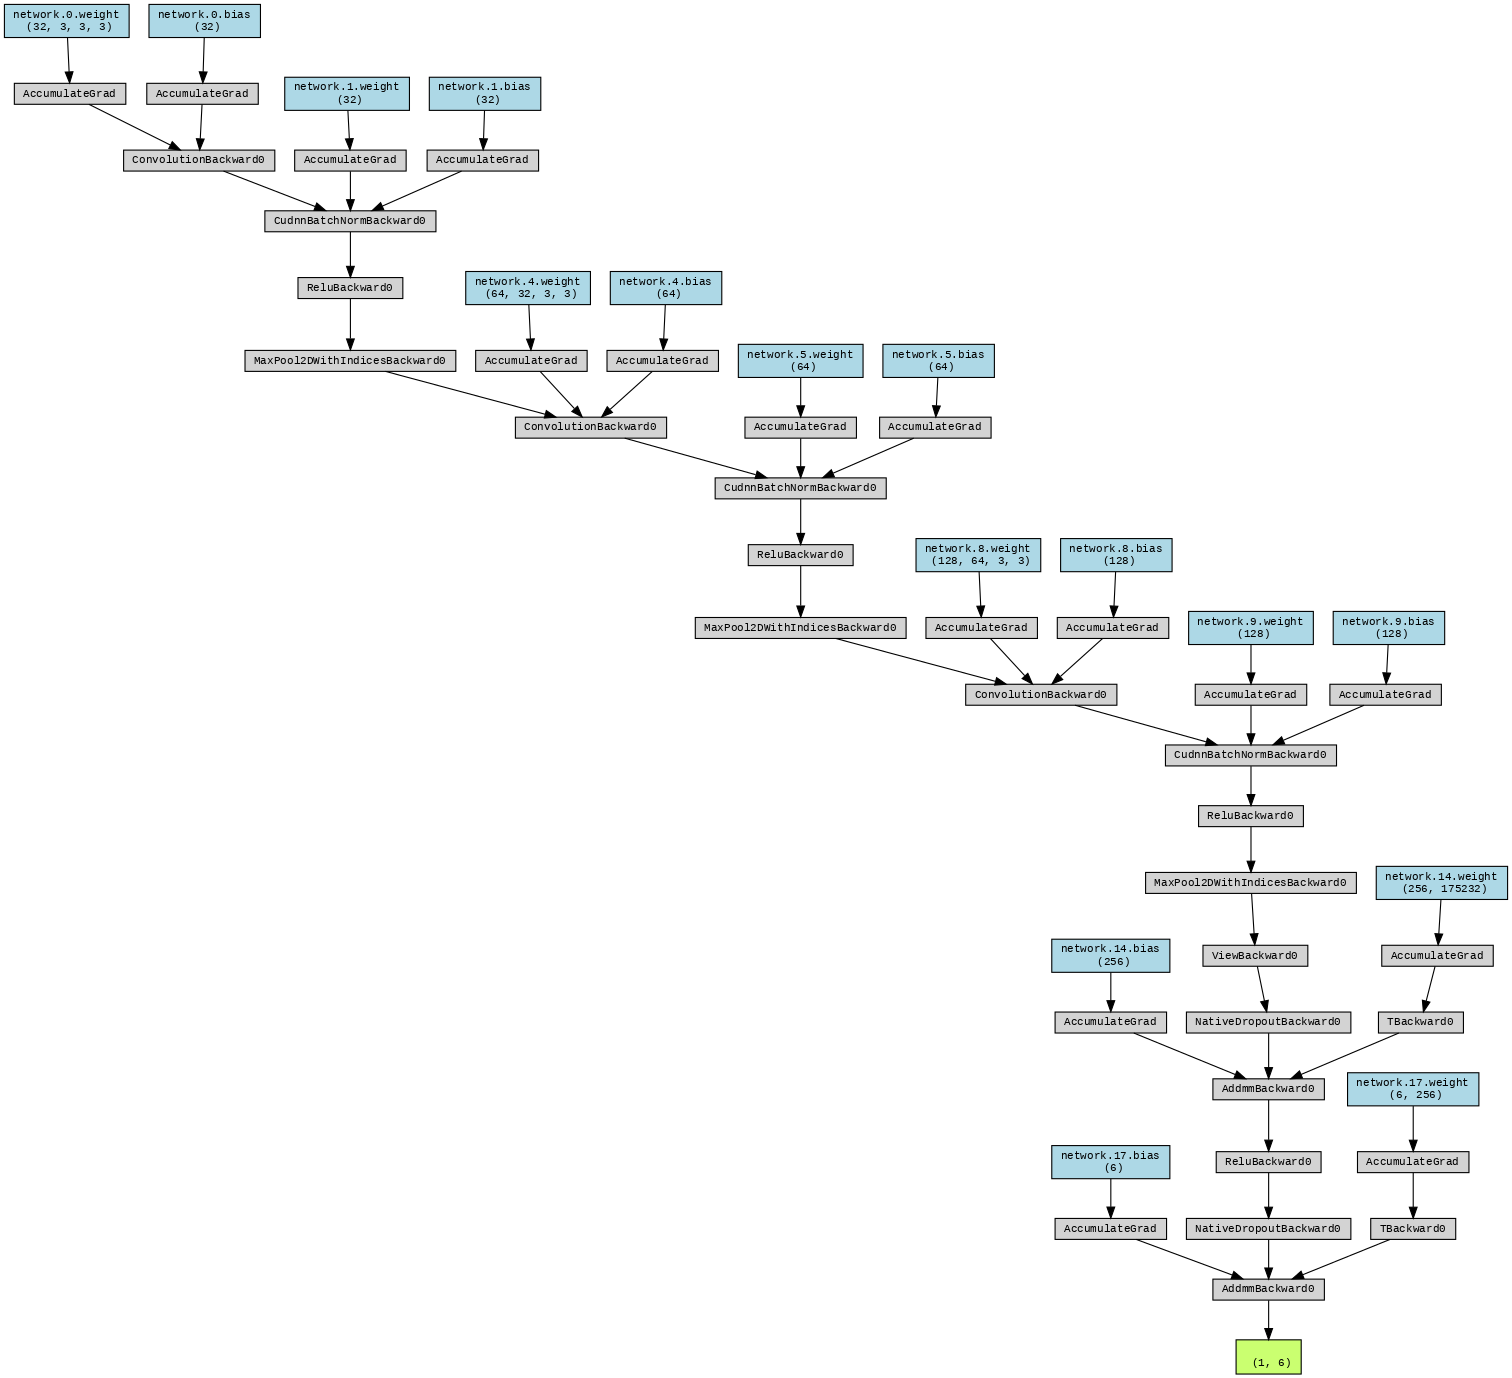

In [9]:

# Create dummy input
dummy_input = torch.randn(1, 3, 300, 300).to(device)

# Forward pass & visualize
output = model(dummy_input)
dot = make_dot(output, params=dict(model.named_parameters()))
dot.format = 'png'
dot.render('ImprovedCNN_architecture')

# Display image
display(Image(filename="ImprovedCNN_architecture.png"))


✅ Step 3: Visualize ResNet-50 Architecture (Modified for Classification)


In [10]:
import torchvision.models as models

# Load pretrained ResNet-50 and modify final layer
resnet_model = models.resnet50(pretrained=True)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, num_classes)
resnet_model = resnet_model.to(device)

print("✅ ResNet-50 Architecture:")
print(resnet_model)

# Create dummy input
dummy_input = torch.randn(1, 3, 300, 300).to(device)

# Forward pass & visualize
output = resnet_model(dummy_input)
dot = make_dot(output, params=dict(resnet_model.named_parameters()))
dot.format = 'png'
dot.render('ResNet50_architecture')

# Display image
display(Image(filename="ResNet50_architecture.png"))


Output hidden; open in https://colab.research.google.com to view.

In [11]:

# Create dummy input
dummy_input = torch.randn(1, 3, 300, 300).to(device)

# Forward pass & visualize
output = resnet_model(dummy_input)
dot = make_dot(output, params=dict(resnet_model.named_parameters()))
dot.format = 'png'
dot.render('ResNet50_architecture')

# Display image
display(Image(filename="ResNet50_architecture.png"))


Output hidden; open in https://colab.research.google.com to view.

Practice

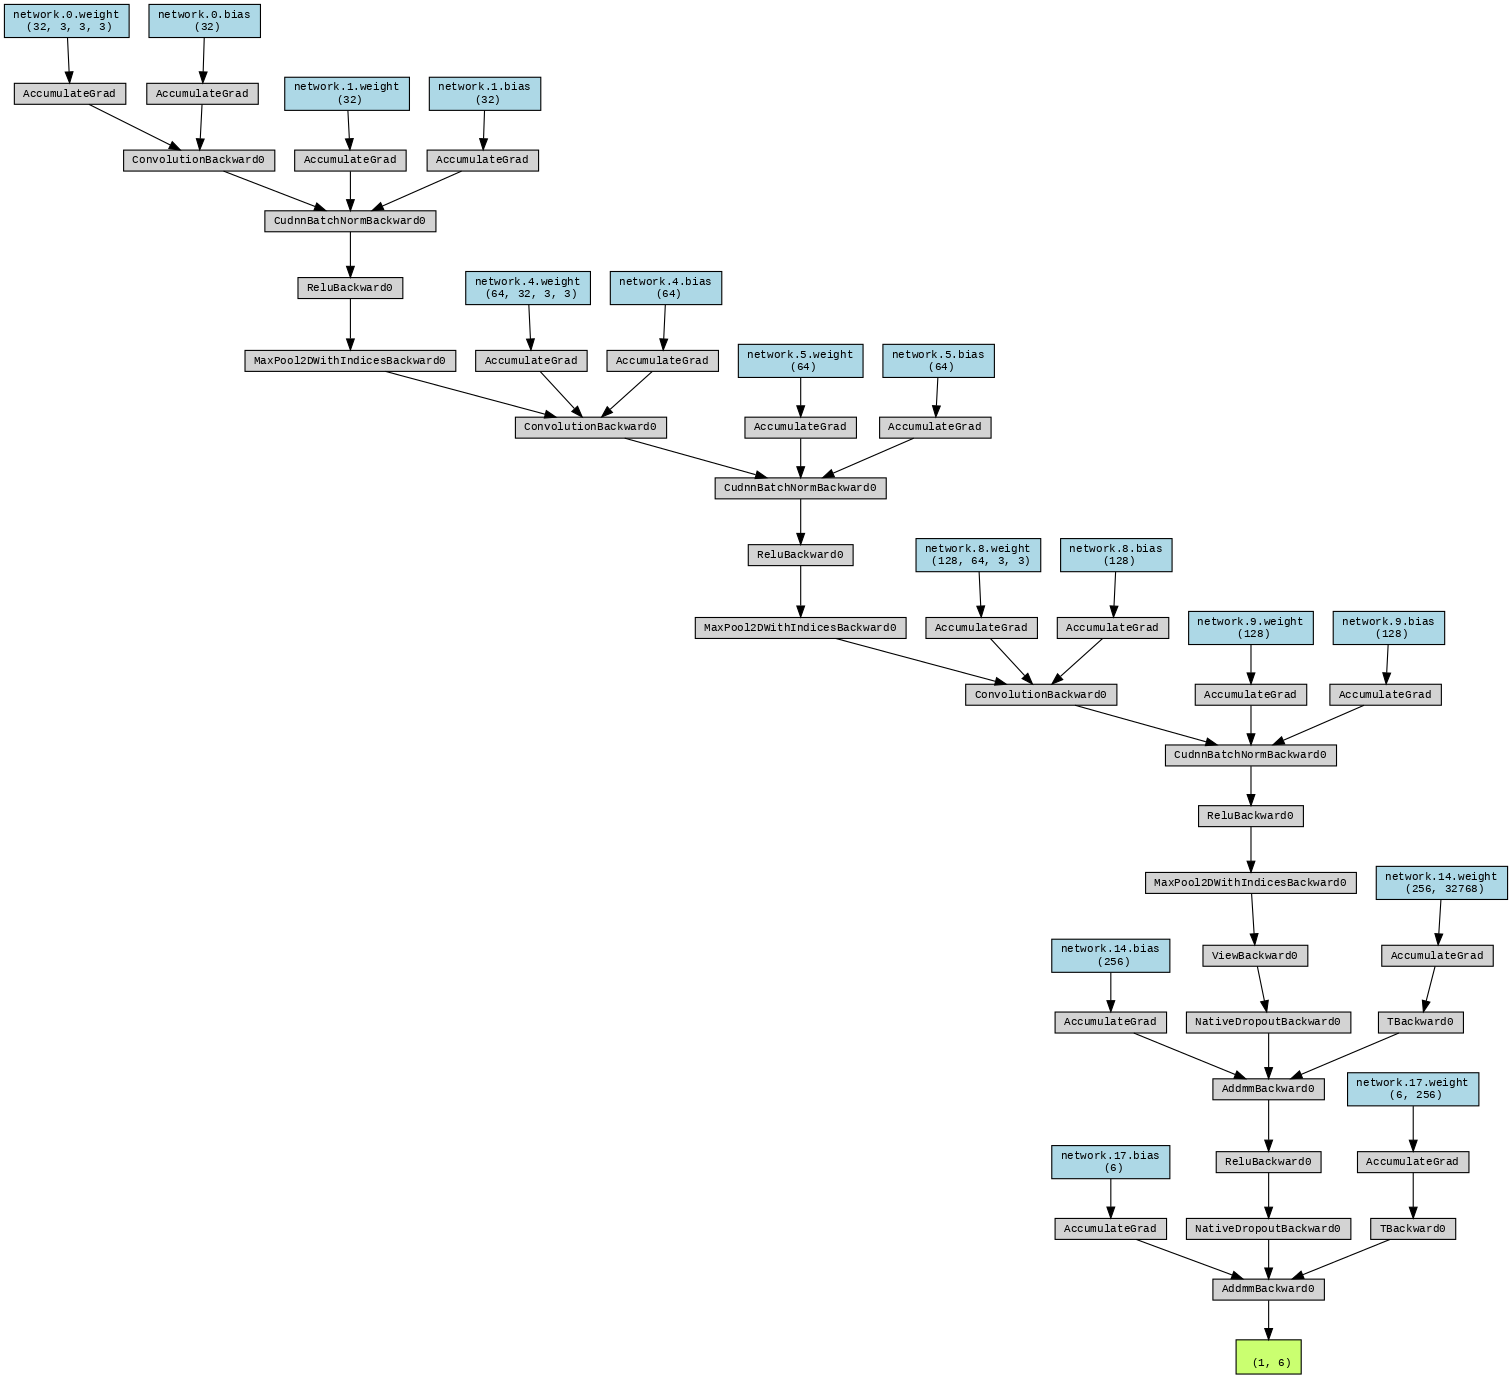

In [12]:
# Install visualization library
# !pip install torchviz

# Import necessary libraries
import torch
import torch.nn as nn
from torchviz import make_dot
from IPython.display import Image, display

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ Smaller version of ImprovedCNN (for visualization only)
class ImprovedCNN_Small(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # -> 64x64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # -> 32x32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # -> 16x16

            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128 * 16 * 16, 256),  # much smaller than 128*37*37
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, xb):
        return self.network(xb)

# Number of classes (from your dataset)
num_classes = 6

# Initialize model
model = ImprovedCNN_Small(num_classes).to(device)

# Dummy input of size 128x128 instead of 300x300
dummy_input = torch.randn(1, 3, 128, 128).to(device)

# Get output and plot
output = model(dummy_input)
dot = make_dot(output, params=dict(model.named_parameters()))
dot.format = 'png'
dot.render('ImprovedCNN_Small_architecture')

# Display image in notebook
display(Image("ImprovedCNN_Small_architecture.png"))
